# Modelado

En el presente notebook se desarrolla el modelado para la clasificación del dataset para endocarditis

## Limpieza de dataset

Para limpieza del dataset se tubieron en cuenta criterios como:
- Eliminar valores de potasio superiores a 10

- Eliminar la columna de neutorfilos al ser una subcategoría de los leucocitos

- Eliminar las variables de texto libre: 
    'ID', target_col, 'Causa de muerte', 'Mortalidad intraoperatoria',
    'Mortalidad en las primeras 48 horas POP', 'Otro procedimiento concomitante',
    'Otro factor predisponente', 'Otro patogeno', 'Otro sitio anatomico para vegetacion',
    'Otro antibiotico', 'Estado vital al  finalizar hospitalizacion'
    
- Eliminar las columnas que tienen mas de 40% de datos faltantes

In [19]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
df=pd.read_excel('data/BD_Endocarditis.xlsx')
# Desenlace: mortalidad intrahospitalaria (1=Muerto)
target_col = 'Estado vital al  finalizar hospitalizacion'
df = df[df[target_col].notna()]  # quita fila sin desenlace
y = (df[target_col] == 'Muerto').astype(int)

print(f"N total: {len(y)} | Muertos: {y.sum()} ({y.mean():.1%})")

N total: 151 | Muertos: 30 (19.9%)


In [20]:
# --- 2. FILTRO PRELIMINAR DE COLUMNAS ---

# Columnas a excluir: IDs, fechas, texto libre, desenlaces
excluir = [
    'ID', target_col, 'Causa de muerte', 'Mortalidad intraoperatoria',
    'Mortalidad en las primeras 48 horas POP', 'Otro procedimiento concomitante',
    'Otro factor predisponente', 'Otro patogeno', 'Otro sitio anatomico para vegetacion',
    'Otro antibiotico', 'Estado vital al  finalizar hospitalizacion'
]
excluir += [c for c in df.columns if 'Fecha' in c]  # excluye fechas

X = df.drop(columns=[c for c in excluir if c in df.columns], errors='ignore')

# --- 2a. LIMPIEZA: PLACEHOLDERS DE FALTANTE A NaN REAL ---

# "No information" aparece como texto en 37 columnas, no como NaN
placeholders = ['No information', 'No informacion', 'NA', 'N/A', 'nan', 'None']
X = X.replace(placeholders, np.nan)  # unifica el faltante real

# Elimina columnas con >40% de datos faltantes (ya corregido)
missing_pct = X.isna().mean()
cols_excluidas_missing = missing_pct[missing_pct > 0.40].index.tolist()
X = X.loc[:, missing_pct <= 0.40]
print(f"Variables tras filtro de missing: {X.shape[1]}")
print(f"Excluidas por >40% missing real: {len(cols_excluidas_missing)}")

# --- 2b. RECLASIFICACION ROBUSTA DE TIPOS ---

num_cols, cat_cols = [], []
for col in X.columns:
    convertido = pd.to_numeric(X[col], errors='coerce')  # intenta a numero
    frac_valida = convertido.notna().sum() / X[col].notna().sum()
    n_unicos = convertido.nunique()
    # Numerica si >=90% convierte y hay variabilidad real
    if frac_valida >= 0.90 and n_unicos > 10:
        X[col] = convertido  # reemplaza por version numerica
        num_cols.append(col)
    else:
        cat_cols.append(col)  # se queda como categorica

print(f"Numericas: {len(num_cols)} | Categoricas: {len(cat_cols)}")

Variables tras filtro de missing: 187
Excluidas por >40% missing real: 14
Numericas: 25 | Categoricas: 162


## Modificación de columnas

In [21]:
# Evita dummies inutiles: descarta categoricas con >15 niveles
cat_cols = [c for c in cat_cols if X[c].nunique() <= 15]
print(f"Categoricas tras filtro cardinalidad: {len(cat_cols)}")

resultados_uni = []

# Numericas: Mann-Whitney U (no asume normalidad)
for col in num_cols:
    grupo1 = X.loc[y == 1, col].dropna()
    grupo0 = X.loc[y == 0, col].dropna()
    if len(grupo1) < 3 or len(grupo0) < 3:
        continue  # muy pocos datos, se omite
    try:
        _, p = mannwhitneyu(grupo1, grupo0, alternative='two-sided')
        resultados_uni.append({'variable': col, 'tipo': 'numerica', 'p_value': p})
    except ValueError:
        continue

# Categoricas: Chi-cuadrado de independencia
for col in cat_cols:
    tabla = pd.crosstab(X[col], y)
    if tabla.shape[0] < 2 or tabla.shape[1] < 2:
        continue  # variable constante, no aporta
    try:
        _, p, _, _ = chi2_contingency(tabla)
        resultados_uni.append({'variable': col, 'tipo': 'categorica', 'p_value': p})
    except ValueError:
        continue

df_uni = pd.DataFrame(resultados_uni).sort_values('p_value')
sig_uni = df_uni[df_uni['p_value'] < 0.05]  # umbral clasico
print(f"\nVariables significativas (univariado p<0.05): {len(sig_uni)}")
print(sig_uni.to_string(index=False))

# --- 4. PREPARACION PARA METODO SELECCION CON LASSO ---

# One-hot para categoricas, mantiene NaN como categoria
X_cat = pd.get_dummies(X[cat_cols].astype(str), dummy_na=True)
X_num = X[num_cols].copy()

# Imputa numericas con la mediana (robusta a outliers)
imputer = SimpleImputer(strategy='median')
X_num_imp = pd.DataFrame(imputer.fit_transform(X_num), columns=num_cols, index=X.index)

X_full = pd.concat([X_num_imp, X_cat], axis=1)

# Escala: necesario para que LASSO penalice de forma justa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# --- 5. SELECCION EMBEBIDA: LOGISTICA CON PENALIZACION L1 ---

# CV con class_weight por el desbalance 20/80
modelo_lasso = LogisticRegressionCV(
    Cs=np.logspace(-3, 1, 20),  # rango amplio, mas penalizacion
    cv=5, penalty='l1', solver='liblinear',
    scoring='roc_auc', class_weight='balanced',
    max_iter=5000, random_state=42
)
modelo_lasso.fit(X_scaled, y)

coefs = pd.Series(modelo_lasso.coef_[0], index=X_full.columns)
seleccion_lasso = coefs[coefs != 0].sort_values(key=abs, ascending=False)

print(f"\nVariables seleccionadas por LASSO: {len(seleccion_lasso)}")
print(seleccion_lasso.to_string())
print(f"\nMejor C (inverso de regularizacion): {modelo_lasso.C_[0]:.4f}")

# --- 6. CONSENSO ENTRE AMBOS METODOS ---

vars_uni = set(sig_uni['variable'])
vars_lasso = set(v.split('_')[0] for v in seleccion_lasso.index)
consenso = vars_uni.intersection(vars_lasso)

print(f"\nVariables en consenso (univariado + LASSO): {len(consenso)}")
print(sorted(consenso))

Categoricas tras filtro cardinalidad: 162

Variables significativas (univariado p<0.05): 22
                                  variable       tipo      p_value
                          Dias antibiotico   numerica 1.321384e-07
                             Shock septico categorica 2.039309e-05
                             Dias estancia   numerica 2.833169e-05
                          Enfermedad renal categorica 9.001743e-04
                          Nitrogeno ureico   numerica 2.670046e-03
                        Aneurisma micotico categorica 5.389252e-03
                                      Edad   numerica 6.311988e-03
                              Leucocitos     numerica 8.829452e-03
                     Sintomas neurologicos categorica 9.750350e-03
                                 Plaquetas   numerica 1.004282e-02
                    Evento cerebrovascular categorica 1.300768e-02
                             Neutrofilos     numerica 1.771991e-02
               Estenosis valvular Aor

### Variables seleccionadas

In [22]:
# agregando variables según criterio clínico
consenso.update({
    'Falla cardiaca',
    'Staphylococcus aureus',
    'Edad'
})
consenso

{'Aneurisma micotico',
 'Dias antibiotico',
 'Edad',
 'Enfermedad renal',
 'Estenosis valvular Aortica)',
 'Falla cardiaca',
 'Fiebre',
 'Hipertension arterial',
 'Shock septico',
 'Sintomas neurologicos',
 'Staphylococcus aureus'}

### Preprocesamiento

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, fbeta_score, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split

In [26]:
# Seleccion columnas
X = df[consenso].copy()

In [31]:
# división dataset con 80 20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,       
    stratify=y,          
    random_state=42
)

In [63]:
y_train.value_counts()/len(y_train)

0    0.8
1    0.2
Name: Estado vital al  finalizar hospitalizacion, dtype: float64

In [64]:
y_test.value_counts()/len(y_test)

0    0.806452
1    0.193548
Name: Estado vital al  finalizar hospitalizacion, dtype: float64

In [37]:
# Preprocesamiento
vars_numericas = ['Edad', 'Dias antibiotico']  # continuas
vars_categoricas = [
    'Aneurisma micotico', 'Enfermedad renal', 'Estenosis valvular Aortica)',
    'Falla cardiaca', 'Fiebre', 'Hipertension arterial',
    'Shock septico', 'Sintomas neurologicos', 'Staphylococcus aureus'
]
# Numericas: mediana (robusta) + estandarizacion
prep_numerico = Pipeline([
    ('imputar', SimpleImputer(strategy='median')),
    ('escalar', StandardScaler())
])

# Categoricas: NaN como categoria propia + one-hot
prep_categorico = Pipeline([
    ('imputar', SimpleImputer(strategy='constant', fill_value='Sin_dato')),
    ('codificar', OneHotEncoder(handle_unknown='ignore'))
])

preprocesador = ColumnTransformer([
    ('num', prep_numerico, vars_numericas),
    ('cat', prep_categorico, vars_categoricas)
])

### Modelo Base

In [38]:
# vamos a usar un dummi clifier para establecer nuestro baseline
# Dummy = baseline real (predice segun patron ingenuo, no "aprende")
modelo_dummy = DummyClassifier(strategy='stratified', random_state=42)
# Beta=2 penaliza mas los falsos negativos que los falsos +
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1, zero_division=0)

metricas = {
    'f2': f2_scorer,
    'recall': 'recall',
    'precision': 'precision',
    'roc_auc': 'roc_auc'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline_dummy = Pipeline([
    ('preprocesar', preprocesador),  # mismo preprocesamiento, por justicia
    ('modelo', modelo_dummy)
])

scores_dummy = cross_validate(
    pipeline_dummy,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas,
    n_jobs=-1,
    error_score='raise'
)
resultado_dummy = {
    'modelo': 'Dummy (baseline azar)',
    'F2_optimizado': scores_dummy['test_f2'].mean(),
    'mejores_params': 'N/A (sin tuning)'
}

print("\n--- BASELINE: DUMMYCLASSIFIER (referencia de azar) ---")
print(f"F2: {resultado_dummy['F2_optimizado']:.4f}")
print(f"Recall: {scores_dummy['test_recall'].mean():.4f} | "
      f"AUC: {scores_dummy['test_roc_auc'].mean():.4f}")


--- BASELINE: DUMMYCLASSIFIER (referencia de azar) ---
F2: 0.2583
Recall: 0.2500 | AUC: 0.5521


### Generación de modelos

In [40]:
#Modelos a evalauar regresión logistíca y supoer vector machine
# Regresion logistica: L2/L1 + pesos balanceados por clase
modelo_logit = LogisticRegression(
    class_weight='balanced', max_iter=2000, random_state=42
)

# SVC con kernel configurable, tambien balanceado
modelo_svc = SVC(
    class_weight='balanced', probability=True, random_state=42
)

In [46]:
## rejillas de hiperparametros
grid_logit = {
    'modelo__C': [0.01, 0.1, 1, 10, 100],      # inverso regularizacion
    'modelo__penalty': ['l1', 'l2'],            # tipo de penalizacion
    'modelo__solver': ['liblinear']              # soporta l1 y l2
}

grid_svc = {
    'modelo__C': [0.1, 1, 10, 100],             # margen de tolerancia
    'modelo__kernel': ['rbf', 'linear'],        # forma de la frontera
    'modelo__gamma': ['scale', 'auto']          # alcance de cada punto
}
grids = {
    'Regresion Logistica': (modelo_logit, grid_logit),
    'SVC': (modelo_svc, grid_svc)
}

In [47]:
resultados_tuning = [resultado_dummy]  # dummy entra solo al reporte final
mejores_modelos = {}

for nombre, (modelo, grid) in grids.items():
    pipeline = Pipeline([
        ('preprocesar', preprocesador),
        ('modelo', modelo)
    ])
    # GridSearchCV: prueba TODAS las combinaciones del diccionario
    busqueda = GridSearchCV(
        estimator=pipeline,
        param_grid=grid,
        scoring=f2_scorer,   # optimiza para F2, no accuracy
        cv=cv,               # mismo StratifiedKFold para todos
        n_jobs=-1,
        refit=True           # reentrena con mejores params al final
    )
    busqueda.fit(X_train, y_train)

    mejores_modelos[nombre] = busqueda.best_estimator_
    resultados_tuning.append({
        'modelo': nombre,
        'F2_optimizado': busqueda.best_score_,
        'mejores_params': busqueda.best_params_
    })
    print(f"\n{nombre}")
    print(f"  Mejor F2: {busqueda.best_score_:.4f}")
    print(f"  Mejores params: {busqueda.best_params_}")

df_tuning = pd.DataFrame(resultados_tuning).sort_values(
    'F2_optimizado', ascending=False
)
print("\n--- COMPARACION FINAL (Dummy aparte + 3 modelos en rejilla) ---")
print(df_tuning.to_string(index=False))


Regresion Logistica
  Mejor F2: 0.7034
  Mejores params: {'modelo__C': 10, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}

SVC
  Mejor F2: 0.7070
  Mejores params: {'modelo__C': 0.1, 'modelo__gamma': 'scale', 'modelo__kernel': 'linear'}

--- COMPARACION FINAL (Dummy aparte + 3 modelos en rejilla) ---
               modelo  F2_optimizado                                                            mejores_params
                  SVC       0.707011  {'modelo__C': 0.1, 'modelo__gamma': 'scale', 'modelo__kernel': 'linear'}
  Regresion Logistica       0.703359 {'modelo__C': 10, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
Dummy (baseline azar)       0.258333                                                          N/A (sin tuning)


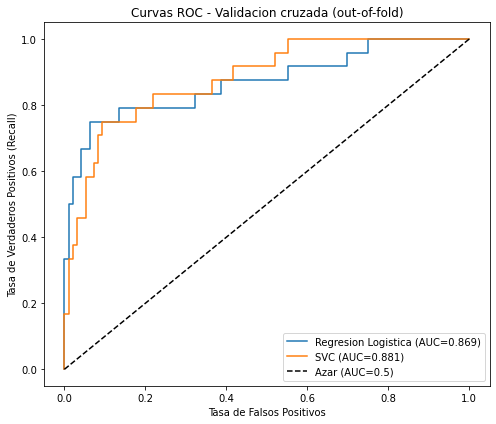

In [54]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import cross_val_predict

plt.figure(figsize=(7, 6))

resultados_roc = {}
for nombre, estimador_ajustado in mejores_modelos.items():
    estimador_limpio = clone(estimador_ajustado)  # sin fit previo

    # predict_proba por fold, cada dato predicho fuera de su fold
    probas = cross_val_predict(
        estimador_limpio, X_train, y_train, cv=cv,
        method='predict_proba', n_jobs=-1
    )[:, 1]  # columna de la clase positiva (Muerto=1)

    fpr, tpr, _ = roc_curve(y_train, probas)  # tasa falsos/verd. positivos
    auc_score = auc(fpr, tpr)
    resultados_roc[nombre] = (fpr, tpr, auc_score, probas)

    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.5)')  # referencia
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curvas ROC - Validacion cruzada (out-of-fold)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.94      0.81      0.87        96
           1       0.51      0.79      0.62        24

    accuracy                           0.81       120
   macro avg       0.73      0.80      0.75       120
weighted avg       0.85      0.81      0.82       120

f2 score 0.7142857142857143
              precision    recall  f1-score   support

           0       0.93      0.86      0.90        96
           1       0.58      0.75      0.65        24

    accuracy                           0.84       120
   macro avg       0.76      0.81      0.78       120
weighted avg       0.86      0.84      0.85       120

f2 score 0.7086614173228347


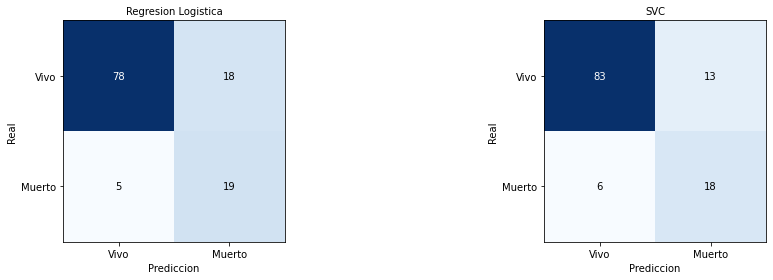

In [58]:
ig, axes = plt.subplots(1, len(mejores_modelos), figsize=(15, 4))

for ax, (nombre, estimador_ajustado) in zip(axes, mejores_modelos.items()):
    estimador_limpio = clone(estimador_ajustado)  # sin fit previo

    pred_clase = cross_val_predict(
        estimador_limpio, X_train, y_train, cv=cv,
        method='predict', n_jobs=-1
    )

    cm = confusion_matrix(y_train, pred_clase)
    clr= classification_report(y_train, pred_clase)
    f2 = fbeta_score(y_train,pred_clase,beta=2,pos_label=1,zero_division=0)
    print(clr)
    print(f'f2 score {f2}')
    ax.imshow(cm, cmap='Blues')  # mapa de calor simple
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Vivo', 'Muerto'])
    ax.set_yticklabels(['Vivo', 'Muerto'])

    # Escribe el numero encima de cada celda
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## Validación

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        25
           1       1.00      0.50      0.67         6

    accuracy                           0.90        31
   macro avg       0.95      0.75      0.81        31
weighted avg       0.91      0.90      0.89        31

0.5555555555555556
              precision    recall  f1-score   support

           0       0.87      0.80      0.83        25
           1       0.38      0.50      0.43         6

    accuracy                           0.74        31
   macro avg       0.62      0.65      0.63        31
weighted avg       0.77      0.74      0.75        31

0.46875


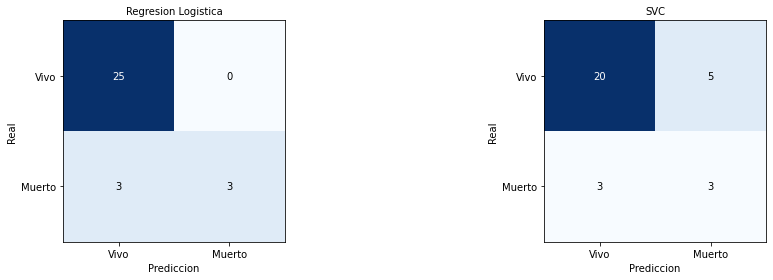

In [61]:
ig, axes = plt.subplots(1, len(mejores_modelos), figsize=(15, 4))

for ax, (nombre, estimador_ajustado) in zip(axes, mejores_modelos.items()):
    estimador_limpio = clone(estimador_ajustado)  # sin fit previo

    pred_clase = cross_val_predict(
        estimador_limpio, X_test, y_test, cv=cv,
        method='predict', n_jobs=-1
    )

    cm = confusion_matrix(y_test, pred_clase)
    clr= classification_report(y_test, pred_clase)
    print(clr)
    f2 = fbeta_score(y_test, pred_clase,beta=2,pos_label=1,zero_division=0)
    print(f2)
    ax.imshow(cm, cmap='Blues')  # mapa de calor simple
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Vivo', 'Muerto'])
    ax.set_yticklabels(['Vivo', 'Muerto'])

    # Escribe el numero encima de cada celda
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

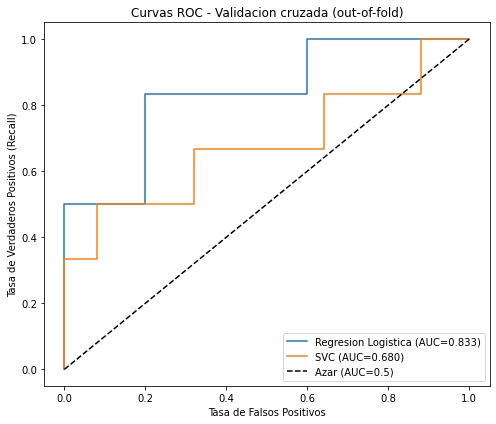

In [62]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import cross_val_predict

plt.figure(figsize=(7, 6))

resultados_roc = {}
for nombre, estimador_ajustado in mejores_modelos.items():
    estimador_limpio = clone(estimador_ajustado)  # sin fit previo

    # predict_proba por fold, cada dato predicho fuera de su fold
    probas = cross_val_predict(
        estimador_limpio, X_test, y_test, cv=cv,
        method='predict_proba', n_jobs=-1
    )[:, 1]  # columna de la clase positiva (Muerto=1)

    fpr, tpr, _ = roc_curve(y_test, probas)  # tasa falsos/verd. positivos
    auc_score = auc(fpr, tpr)
    resultados_roc[nombre] = (fpr, tpr, auc_score, probas)

    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.5)')  # referencia
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curvas ROC - Validacion cruzada (out-of-fold)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()